<a href="https://colab.research.google.com/github/lax-17/Fmri-to-image/blob/main/U_Net_PatchGAN_with_LSGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline GAN model for assessment

**Module:** Deep Neural Networks and Learning Systems

In this demonstration and notebook, we will develop a baseline model for your assessment task.


---


**Objectives:**

- Develop the baseline convolutional GAN
- Understand the potential modifications to this model to be performed as an assessment

## Setting up the dataset

The dataset is located in a different drive (public). Therefore, we need to add a shortcut to the data directory in our own drive.

**Original dataset**

Open the dataset external drive: [https://drive.google.com/drive/folders/1DUf3nGNNFk6YjRjQtZPfAY5N105GoGJb](https://drive.google.com/drive/folders/1DUf3nGNNFk6YjRjQtZPfAY5N105GoGJb) and click in add shortcut.


## Utility functions

The following functions can be used to load the FMRI data from a given subject, load activity from a given region of interest or loading the corresponding image.

In [ ]:
# Core libraries
import os, glob, joblib, shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.decomposition import PCA

import time
import random
import imageio
import re

# PyTorch related
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils # For saving image grids


# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Loading Data


In [ ]:
root_dir = '/kaggle/input/algonauts-2023-tutorial-data'
algonauts_dir = 'algonauts_2023_tutorial_Data' # Path to the shortcut in your drive
algonauts_path = os.path.join(root_dir, algonauts_dir)

In [ ]:
# @title Helper functions
# Loads all the fmri data associated to a given subject
def load_fmri_of_subject( subj, hemisphere, directory = root_dir ):
  subj = subj # Subject
  hemisphere = hemisphere # Which side of the brain
  # Listing directory
  subj = format(subj, '02')
  data_dir = os.path.join(directory, algonauts_dir )
  data_dir = os.path.join(data_dir, 'subj' + subj) # subj01
  fmri_dir = os.path.join(data_dir, 'training_split', 'training_fmri') # Location the brain activation
  # Here we load the data
  if hemisphere == 'left':
    brain_activity = np.load(os.path.join(fmri_dir, 'lh_training_fmri.npy'))
  else:
    brain_activity = np.load(os.path.join(fmri_dir, 'rh_training_fmri.npy'))
  return brain_activity

def load_fmri_region_of_interest( subj, roi, hemisphere, directory = root_dir):
  subj = format(subj, '02')
  data_dir = os.path.join(directory, algonauts_dir )
  data_dir = os.path.join(data_dir, 'subj' + subj) # subj01
    # Define the ROI class based on the selected ROI
  if roi in ["V1v", "V1d", "V2v", "V2d", "V3v", "V3d", "hV4"]:
      roi_class = 'prf-visualrois'
  elif roi in ["EBA", "FBA-1", "FBA-2", "mTL-bodies"]:
      roi_class = 'floc-bodies'
  elif roi in ["OFA", "FFA-1", "FFA-2", "mTL-faces", "aTL-faces"]:
      roi_class = 'floc-faces'
  elif roi in ["OPA", "PPA", "RSC"]:
      roi_class = 'floc-places'
  elif roi in ["OWFA", "VWFA-1", "VWFA-2", "mfs-words", "mTL-words"]:
      roi_class = 'floc-words'
  elif roi in ["early", "midventral", "midlateral", "midparietal", "ventral", "lateral", "parietal"]:
      roi_class = 'streams'

  # Loading the roi masks (To locate the activations of a given region)
  roi_class_dir = os.path.join(data_dir, 'roi_masks',
      hemisphere[0]+'h.'+roi_class+'_challenge_space.npy')
  roi_map_dir = os.path.join(data_dir, 'roi_masks',
      'mapping_'+roi_class+'.npy')
  roi_class_idx = np.load(roi_class_dir)
  roi_map = np.load(roi_map_dir, allow_pickle=True).item()
  roi_mapping = list(roi_map.keys())[list(roi_map.values()).index(roi)]
  challenge_roi = np.asarray(roi_class_idx == roi_mapping, dtype=int)

  # Selection the appropriate data
  fmri_dir = os.path.join(data_dir, 'training_split', 'training_fmri') # Location the brain activation
  # Here we load the data
  if hemisphere == 'left':
    brain_activity = np.load(os.path.join(fmri_dir, 'lh_training_fmri.npy'))
  else:
    brain_activity = np.load(os.path.join(fmri_dir, 'rh_training_fmri.npy'))

  fmri_roi_data = brain_activity[:,np.where(challenge_roi)[0]]

  return fmri_roi_data

# Load a particular image from a subject
def load_image_subject( subj, img, directory = root_dir):
  subj = format(subj, '02')
  data_dir = os.path.join(directory, algonauts_dir )
  data_dir = os.path.join(data_dir, 'subj' + subj) # subj01
  train_img_dir  = os.path.join(data_dir, 'training_split', 'training_images')
  test_img_dir  = os.path.join(data_dir, 'test_split', 'test_images')
  train_img_list = os.listdir(train_img_dir)
  train_img_list.sort()
  test_img_list = os.listdir(test_img_dir)
  test_img_list.sort()

  img_dir = os.path.join(train_img_dir, train_img_list[img])
  train_img = Image.open(img_dir).convert('RGB') # Image library (PIL)
  return train_img

def showImage( ax, image, title = '' ):
  ''' This is a helper function that allows you to show the results of your training '''
  image = (image - torch.min(image))/(torch.max(image)-torch.min(image)) # image 0...1
  ax.imshow(image.permute(1,2,0)) # You need reorganize the dimension (3, H,  W) -> (H, W, 3)
  ax.set_title(title)


## Bulding Dataset


Loading WHOLE HEMISPHERE fMRI data and computing PCA from scratch...
Loading full left hemisphere fMRI data for subject 1...
Loaded raw data shape: (9841, 19004)
Fitting PCA (1024 components)... (WARNING: May be RAM intensive!)
PCA fitting complete. Output shape: (9841, 1024)
Saving PCA model to /kaggle/working/cdcgan_pca_whole_hemi_1024/pca_1024.joblib
Saving fMRI latent matrix to /kaggle/working/cdcgan_pca_whole_hemi_1024/fmri_pca_1024.npy
Instantiating dataset with preloading...
Preloading 9841 images...


Loading images:   0%|          | 0/9841 [00:00<?, ?it/s]

Stacked images.
Finished preloading 9841 images in 242.78s.
Dataset instantiated.
Setting num_workers to 0 due to preloading.
Dataset and DataLoader created. Num samples: 9841
Sample batch shapes: Image: torch.Size([32, 3, 64, 64]) fMRI PCA: torch.Size([32, 1024])


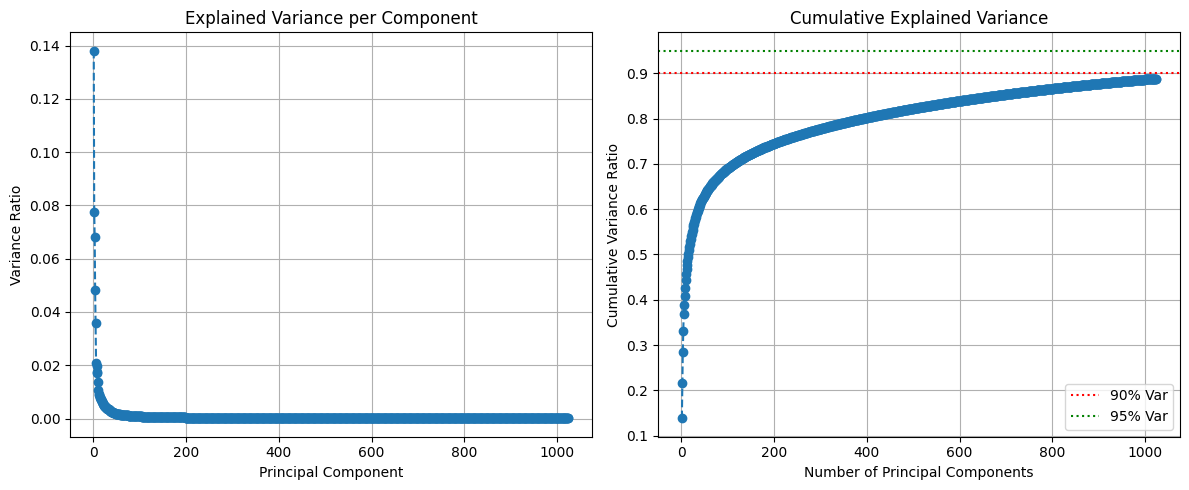

Total variance explained by 1024 components: 88.86%


In [ ]:

TARGET_SUBJECT = 1
TARGET_HEMISPHERE = 'left'
IMAGE_SIZE = 64

N_COMPONENTS = 1024

BATCH_SIZE = 32
NUM_WORKERS = 0


img_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


PCA_SAVE_DIR = f'/kaggle/working/cdcgan_pca_whole_hemi_{N_COMPONENTS}' # <<< NEW DIR NAME
PCA_MODEL_PATH = os.path.join(PCA_SAVE_DIR, f'pca_{N_COMPONENTS}.joblib')
FMRI_LATENT_PATH = os.path.join(PCA_SAVE_DIR, f'fmri_pca_{N_COMPONENTS}.npy')

RAW_DATA_DIR = '/kaggle/working/cdcgan_pca_whole_hemi' # <<< Point to where raw was saved
HEMI_DATA_RAW_PATH = os.path.join(RAW_DATA_DIR, f'fmri_{TARGET_HEMISPHERE}_hemi_raw.npy')

os.makedirs(PCA_SAVE_DIR, exist_ok=True)

fmri_pca_components = None
fmri_raw_data_np = None
pca = None


if os.path.exists(PCA_MODEL_PATH) and os.path.exists(FMRI_LATENT_PATH):
    print(f"Loading existing PCA model and fMRI latent matrix for {N_COMPONENTS} components...")
    pca = joblib.load(PCA_MODEL_PATH)
    fmri_pca_components = np.load(FMRI_LATENT_PATH)
    print(f"Loaded PCA components shape: {fmri_pca_components.shape}")

elif os.path.exists(HEMI_DATA_RAW_PATH):
    print(f"Loading existing raw WHOLE HEMISPHERE fMRI data...")
    fmri_raw_data_np = np.load(HEMI_DATA_RAW_PATH)
    print(f"Loaded raw hemisphere fMRI data shape: {fmri_raw_data_np.shape}")
    print(f"Fitting PCA ({N_COMPONENTS} components)... (WARNING: May be RAM intensive!)")
    try:
        pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
        fmri_pca_components = pca.fit_transform(fmri_raw_data_np)
        print(f"PCA fitting complete. Output shape: {fmri_pca_components.shape}")
        print(f"Saving PCA model to {PCA_MODEL_PATH}")
        print(f"Saving fMRI latent matrix to {FMRI_LATENT_PATH}")
        joblib.dump(pca, PCA_MODEL_PATH)
        np.save(FMRI_LATENT_PATH, fmri_pca_components)
    except MemoryError as e:
         print(f"ERROR: MemoryError during PCA fitting for {N_COMPONENTS} components. Try fewer components or a machine with more RAM.")
         fmri_pca_components = None
    except Exception as e:
         print(f"Error during PCA fitting: {e}")
         fmri_pca_components = None

else:
    print("Loading WHOLE HEMISPHERE fMRI data and computing PCA from scratch...")
    try:
        print(f"Loading full {TARGET_HEMISPHERE} hemisphere fMRI data for subject {TARGET_SUBJECT}...")
        if 'root_dir' not in globals() or 'algonauts_dir' not in globals(): raise NameError("Paths missing.")
        fmri_raw_data_np = load_fmri_of_subject(TARGET_SUBJECT, TARGET_HEMISPHERE, directory=root_dir)
        if fmri_raw_data_np is None or fmri_raw_data_np.size == 0: raise ValueError("Failed to load fMRI data.")
        print(f"Loaded raw data shape: {fmri_raw_data_np.shape}")
        # Fit PCA
        print(f"Fitting PCA ({N_COMPONENTS} components)... (WARNING: May be RAM intensive!)")
        pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
        fmri_pca_components = pca.fit_transform(fmri_raw_data_np)
        print(f"PCA fitting complete. Output shape: {fmri_pca_components.shape}")
        # Save PCA model and transformed data
        print(f"Saving PCA model to {PCA_MODEL_PATH}")
        print(f"Saving fMRI latent matrix to {FMRI_LATENT_PATH}")
        joblib.dump(pca, PCA_MODEL_PATH)
        np.save(FMRI_LATENT_PATH, fmri_pca_components)
    except (ValueError, FileNotFoundError, IndexError, MemoryError, NameError) as e:
        print(f"Error during data loading or PCA: {e}")
        fmri_pca_components = None

class FMRI_Image_PCA_Dataset(Dataset):
    # ... (Keep preloading __init__ and __getitem__ from previous answer) ...
    def __init__(self, subject, fmri_pca_data, transform=None):
        self.subject = subject
        self.fmri_pca = torch.from_numpy(fmri_pca_data).float()
        self.transform = transform
        self.num_samples = fmri_pca_data.shape[0]
        self.images = []
        print(f"Preloading {self.num_samples} images..."); T_start=time.time()
        for idx in tqdm(range(self.num_samples), desc="Loading images"): # Use standard tqdm here
            img = load_image_subject(self.subject, idx, directory=root_dir);
            if img is None: img = torch.zeros((3, IMAGE_SIZE, IMAGE_SIZE))
            elif self.transform: img = self.transform(img)
            else: img = transforms.ToTensor()(img)
            self.images.append(img)
        try: self.images = torch.stack(self.images); print("Stacked images.")
        except: print("Keeping images as list.")
        print(f"Finished preloading {len(self.images)} images in {time.time()-T_start:.2f}s.")
    def __len__(self): return self.num_samples
    def __getitem__(self, idx): return self.images[idx], self.fmri_pca[idx]


dataset = None
dataloader = None
if fmri_pca_components is not None:
    print("Instantiating dataset with preloading...")
    try:
        dataset = FMRI_Image_PCA_Dataset(TARGET_SUBJECT, fmri_pca_components, transform=img_transform)
        print("Dataset instantiated.")
        print(f"Setting num_workers to {NUM_WORKERS} due to preloading.")
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False)
        print(f"Dataset and DataLoader created. Num samples: {len(dataset)}")
        img_batch, fmri_batch = next(iter(dataloader))
        print("Sample batch shapes: Image:", img_batch.shape, "fMRI PCA:", fmri_batch.shape)
    except Exception as e: print(f"Error creating Dataset/DataLoader: {e}"); dataset=None; dataloader=None
else:
    print("Dataset/DataLoader creation skipped due to PCA errors.")


if pca is not None and fmri_pca_components is not None:
    explained_variance = pca.explained_variance_ratio_
    cumulative_explained_variance = np.cumsum(explained_variance)
    plt.figure(figsize=(12, 5)); plt.subplot(1, 2, 1); plt.plot(range(1, N_COMPONENTS + 1), explained_variance, marker='o', linestyle='--'); plt.title('Explained Variance per Component'); plt.xlabel('Principal Component'); plt.ylabel('Variance Ratio'); plt.grid(True); plt.subplot(1, 2, 2); plt.plot(range(1, N_COMPONENTS + 1), cumulative_explained_variance, marker='o', linestyle='--'); plt.title('Cumulative Explained Variance'); plt.xlabel('Number of Principal Components'); plt.ylabel('Cumulative Variance Ratio'); plt.axhline(y=0.9, color='r', linestyle=':', label='90% Var'); plt.axhline(y=0.95, color='g', linestyle=':', label='95% Var'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    print(f"Total variance explained by {N_COMPONENTS} components: {cumulative_explained_variance[-1]*100:.2f}%")
else:
    print("PCA object or components not available for plotting.")

## Models cDCGAN

In [ ]:

try:
    if 'N_COMPONENTS' not in globals(): raise NameError("N_COMPONENTS not defined")
    fMRI_dim = N_COMPONENTS
    # Set other defaults if needed
    if 'embedding_dim' not in globals(): embedding_dim = 128
    if 'nz' not in globals(): nz = 100
    if 'ngf' not in globals(): ngf = 64 # Base features for Generator
    if 'ndf' not in globals(): ndf = 64 # Base features for Discriminator
    if 'nc' not in globals(): nc = 3
    if 'IMAGE_SIZE' not in globals(): IMAGE_SIZE = 64
    print(f"Defining U-Net with fMRI_dim={fMRI_dim}, nz={nz}, embedding_dim={embedding_dim}, img_size={IMAGE_SIZE}")
except NameError as e:
    print(f"ERROR: Parameter missing: {e}")
    # Set dummy values to allow class definition
    N_COMPONENTS=256; fMRI_dim = N_COMPONENTS; embedding_dim=128; nz=100; ngf=64; ndf=64; nc=3; IMAGE_SIZE=64

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- Custom weight initialization ---
def weights_init(m):
    # ... (keep weights_init function as before) ...
    classname = m.__class__.__name__
    if classname.find('Conv') != -1: nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1: nn.init.normal_(m.weight.data, 1.0, 0.02); nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1: nn.init.normal_(m.weight.data, 0.0, 0.02);
    if hasattr(m, 'bias') and m.bias is not None: nn.init.constant_(m.bias.data, 0)


# --- U-Net Generator Blocks ---
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size)) # InstanceNorm often used in Pix2Pix/CycleGAN
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0, add_condition_dim=0):
        super(UNetUp, self).__init__()

        total_in_size = in_size + in_size + add_condition_dim
        layers = [
            nn.ConvTranspose2d(total_in_size, out_size, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input, condition_spatial=None):
        x = self.model[0](torch.cat([x, skip_input], 1))
        x = self.model[1](x) # Norm

        if condition_spatial is not None:
             x = torch.cat([x, condition_spatial], dim=1)

        concat_input = torch.cat([x, skip_input], 1)
        if condition_spatial is not None:
            if condition_spatial.shape[2:] != concat_input.shape[2:]:
                 condition_spatial = F.interpolate(condition_spatial, size=concat_input.shape[2:], mode='nearest')
            concat_input = torch.cat([concat_input, condition_spatial], 1)
        return self.model(concat_input) # This needs fixing


# --- Generator (U-Net Style) ---
class Generator(nn.Module):
    def __init__(self, noise_dim=nz, condition_dim=fMRI_dim, embed_cond_dim=embedding_dim, output_channels=nc):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.condition_dim = condition_dim
        self.embed_cond_dim = embed_cond_dim

        self.fmri_embed = nn.Linear(condition_dim, embed_cond_dim)

        start_size = 4
        combined_input_dim = noise_dim + embed_cond_dim
        self.project = nn.Linear(combined_input_dim, ngf * 8 * start_size * start_size)
        self.bn_init = nn.BatchNorm2d(ngf * 8)
        self.relu_init = nn.ReLU(True)
        self.start_size = start_size
        self.down1 = UNetDown(ngf * 8, ngf * 8) # 4x4 -> 2x2 (If start_size=8, input is ngf*4) - Adjust channels/size!

        self.up_init = nn.Sequential(
            nn.ConvTranspose2d(combined_input_dim, ngf * 8, 4, 1, 0, bias=False), # -> 4x4
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True)
        )
        self.up1 = nn.Sequential( # 4x4 -> 8x8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True))
        self.up2 = nn.Sequential( # 8x8 -> 16x16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True))
        self.up3 = nn.Sequential( # 16x16 -> 32x32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True))
        self.up4 = nn.Sequential( # 32x32 -> 64x64
            nn.ConvTranspose2d(ngf, output_channels, 4, 2, 1, bias=False),
            nn.Tanh()) # Final output


    def forward(self, noise, fmri_condition):
        fmri_embedded = self.fmri_embed(fmri_condition)
        gen_input = torch.cat((noise, fmri_embedded), 1)
        out = self.up_init(gen_input.unsqueeze(-1).unsqueeze(-1)) # Project to 4x4
        out = self.up1(out)
        out = self.up2(out)
        out = self.up3(out)
        out = self.up4(out)
        return out

# --- Discriminator (PatchGAN Style - Often used with U-Net Generators) ---

class Discriminator(nn.Module):
    def __init__(self, input_nc=nc, condition_nc=embedding_dim, ndf=ndf, n_layers=3): # Condition concatenated as channel
        super(Discriminator, self).__init__()

        # Embed fMRI condition
        self.fmri_embed = nn.Linear(fMRI_dim, embedding_dim)

        kernel_size = 4
        padw = 1
        # Concatenate image and spatially replicated condition embedding
        sequence = [nn.Conv2d(input_nc + embedding_dim, ndf, kernel_size=kernel_size, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):  # gradually increase the number of filters
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kernel_size, stride=2, padding=padw, bias=False),
                nn.InstanceNorm2d(ndf * nf_mult), # Use InstanceNorm
                nn.LeakyReLU(0.2, True)
            ]

        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kernel_size, stride=1, padding=padw, bias=False),
            nn.InstanceNorm2d(ndf * nf_mult),
            nn.LeakyReLU(0.2, True)
        ]

        # Output 1 channel prediction map
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kernel_size, stride=1, padding=padw)]
        # NO Sigmoid for LSGAN/WGAN-GP

        self.model = nn.Sequential(*sequence)

    def forward(self, img, fmri_condition):
        # Embed condition and replicate spatially
        fmri_embedded = self.fmri_embed(fmri_condition) # [B, embed_dim]
        # Reshape and tile to match image H, W
        fmri_spatial = fmri_embedded.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, img.size(2), img.size(3))

        # Concatenate along channel dimension
        combined_input = torch.cat([img, fmri_spatial], 1) # [B, nc+embed_dim, H, W]

        output = self.model(combined_input)
        return output # Return the map (e.g., [B, 1, 7, 7]) - Loss function handles averaging


netG = None; netD = None; models_defined = False
try:
    # Use the U-Net Style Generator and PatchGAN Discriminator
    netG = Generator(noise_dim=nz, condition_dim=fMRI_dim, embed_cond_dim=embedding_dim, output_channels=nc).to(device)
    netD = Discriminator(input_nc=nc, condition_nc=embedding_dim, ndf=ndf).to(device) # Critic

    netG.apply(weights_init)
    netD.apply(weights_init)
    print("--- Generator (U-Net Style) ---")
    # print(netG)
    print("--- Critic/Discriminator (PatchGAN Style) ---")
    # print(netD)
    print("U-Net based Conditional GAN Models defined.")
    models_defined = True
except NameError as e: print(f"ERROR: Required parameters not defined: {e}")
except Exception as e: print(f"Error during model instantiation: {e}")

Defining U-Net with fMRI_dim=1024, nz=100, embedding_dim=128, img_size=64
--- Generator (U-Net Style) ---
--- Critic/Discriminator (PatchGAN Style) ---
U-Net based Conditional GAN Models defined.


## Training for 1000 epochs

### Training setup

In [ ]:

if 'dataloader' not in locals() or dataloader is None:
     print("ERROR: DataLoader not found. Please run Cell 3 successfully first.")
     ready_to_train = False
elif 'models_defined' not in locals() or not models_defined:
     print("ERROR: Generator (netG) or Discriminator (netD) not defined. Please run Cell 4 successfully first.")
     ready_to_train = False
else:
    ready_to_train = True

if ready_to_train:

    NUM_EPOCHS = 1000
    LR_G = 0.0002
    LR_D = 0.0001
    WEIGHT_DECAY = 0
    BETA1 = 0.5



    OUTPUT_BASE_DIR = f'/kaggle/working/pca-SNGAN{N_COMPONENTS}' # <<< Folder name reflects PCA components
    PREVIEW_DIR_LSGAN = os.path.join(OUTPUT_BASE_DIR, 'previews')
    CHECKPOINT_DIR_LSGAN = os.path.join(OUTPUT_BASE_DIR, 'checkpoints')
    LOSS_CURVE_G_PATH = os.path.join(OUTPUT_BASE_DIR, 'g_losses.npy')
    LOSS_CURVE_D_PATH = os.path.join(OUTPUT_BASE_DIR, 'd_losses.npy')
    REAL_SAMPLES_PATH = os.path.join(OUTPUT_BASE_DIR, 'real_samples_for_preview.png')
    FIXED_NOISE_PATH = os.path.join(OUTPUT_BASE_DIR, 'fixed_noise.pt')
    FIXED_FMRI_PATH = os.path.join(OUTPUT_BASE_DIR, 'fixed_fmri_condition.pt')
    REAL_IMAGES_PREVIEW_PATH = os.path.join(OUTPUT_BASE_DIR, 'real_images_preview.pt')

    os.makedirs(PREVIEW_DIR_LSGAN, exist_ok=True)
    os.makedirs(CHECKPOINT_DIR_LSGAN, exist_ok=True)
    print(f"Outputs will be saved to: {OUTPUT_BASE_DIR}")


    PREVIEW_EVERY = 20     # Adjust
    CHECKPOINT_EVERY = 100 # Adjust


    fixed_noise = None; fixed_fmri_condition = None; real_images_for_preview = None
    try:
        if BATCH_SIZE != dataloader.batch_size: # Recreate if BS changed
             print(f"Recreating dataloader with batch size: {BATCH_SIZE}")
             dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True if device.type == 'cuda' else False)

        fixed_real_batch, fixed_fmri_batch = next(iter(dataloader))
        preview_batch_size = min(BATCH_SIZE, 16)
        fixed_noise = torch.randn(preview_batch_size, nz, device=device)
        fixed_fmri_condition = fixed_fmri_batch[:preview_batch_size].to(device)
        real_images_for_preview = fixed_real_batch[:preview_batch_size]
        print(f"Using fixed fMRI conditions (shape: {fixed_fmri_condition.shape}) for previews (Batch Size: {BATCH_SIZE})")
        if not os.path.exists(REAL_SAMPLES_PATH): vutils.save_image(real_images_for_preview * 0.5 + 0.5, REAL_SAMPLES_PATH, normalize=False, padding=2); print(f"Saved real samples.")
        else: print(f"Real samples file exists.")
        # Save fixed tensors
        torch.save(fixed_noise, FIXED_NOISE_PATH); torch.save(fixed_fmri_condition, FIXED_FMRI_PATH); torch.save(real_images_for_preview, REAL_IMAGES_PREVIEW_PATH)
        print(f"Saved fixed tensors for visualization.")
    except Exception as e: print(f"Warning: Could not set fixed batch: {e}"); ready_to_train = False # Stop if we can't get preview data


    real_label_val = 1.0
    fake_label_val = 0.0
    criterion = nn.MSELoss()
    print("Using MSELoss (LSGAN)")


    optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999), weight_decay=WEIGHT_DECAY)
    optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999), weight_decay=WEIGHT_DECAY)
    print(f"Optimizers initialized with LR_G={LR_G}, LR_D={LR_D}")

    img_list = []
    G_losses_iter = [] # Changed to iter losses
    D_losses_iter = []

    print("Training setup complete.")

else:
    print("ERROR: Cannot proceed with setup.")

Confirming device: cuda:0
Outputs will be saved to: /kaggle/working/pca-SNGAN1024
Using fixed fMRI conditions (shape: torch.Size([16, 1024])) for previews (Batch Size: 32)
Saved real samples.
Saved fixed tensors for visualization.
Using MSELoss (LSGAN)
Optimizers initialized with LR_G=0.0002, LR_D=0.0001
Training setup complete.


In [ ]:
# Cell 6: Training Loop (Conditional U-Net/PatchGAN with LSGAN)

import torch.autograd as autograd
import time


if 'ready_to_train' in locals() and ready_to_train and \
   'fixed_fmri_condition' in locals() and fixed_fmri_condition is not None and \
   'fixed_noise' in locals() and fixed_noise is not None:

    print(f"Starting Conditional LSGAN Training Loop (U-Net/PatchGAN) for {NUM_EPOCHS} epochs...")
    iters = 0
    start_time = time.time()
    final_epoch = 0

    # Initialize or load loss lists
    if 'G_losses_iter' not in locals() or ('epoch' in locals() and epoch == 1): G_losses_iter = []
    if 'D_losses_iter' not in locals() or ('epoch' in locals() and epoch == 1): D_losses_iter = []
    if 'img_list' not in locals() or ('epoch' in locals() and epoch == 1): img_list = []

    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_start_time = time.time()
        netG.train()
        netD.train() # Discriminator
        final_epoch = epoch
        epoch_g_loss_accum = 0.0
        epoch_d_loss_accum = 0.0
        valid_g_iters = 0
        valid_d_iters = 0

        progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}/{NUM_EPOCHS}")

        for i, data in progress_bar:
            real_img = data[0].to(device)
            fmri_cond = data[1].to(device)
            b_size = real_img.size(0)

            netD.zero_grad()

            # --- Real batch pass ---
            output_real = netD(real_img, fmri_cond)       # Output is a patch map
            label_real = torch.full_like(output_real, real_label_val, device=device) # Target map of 1s
            errD_real = criterion(output_real, label_real) # MSE(D(x), 1)
            if torch.isfinite(errD_real): errD_real.backward()
            else: print(f"W: NaN/Inf D_real e:{epoch} i:{i}"); errD_real = torch.tensor(0.0)
            D_x = output_real.mean().item() # Average score on real patches

            # --- Fake batch pass ---
            noise = torch.randn(b_size, nz, device=device)
            fake = netG(noise, fmri_cond)
            output_fake = netD(fake.detach(), fmri_cond) # Output is a patch map
            label_fake = torch.full_like(output_fake, fake_label_val, device=device) # Target map of 0s
            errD_fake = criterion(output_fake, label_fake) # MSE(D(G(z)), 0)
            if torch.isfinite(errD_fake): errD_fake.backward()
            else: print(f"W: NaN/Inf D_fake e:{epoch} i:{i}"); errD_fake = torch.tensor(0.0)

            errD = 0.5 * (errD_real + errD_fake) # Standard LSGAN D loss scaling
            if torch.isfinite(errD_real) and torch.isfinite(errD_fake): optimizerD.step()
            else: print(f"W: Skip D step e:{epoch} i:{i}")

            D_G_z1 = output_fake.mean().item() # Average score on fake patches (before G update)

            netG.zero_grad()

            noise = torch.randn(b_size, nz, device=device)
            fake_for_g = netG(noise, fmri_cond)
            output_g = netD(fake_for_g, fmri_cond)

            label_g = torch.full_like(output_g, real_label_val, device=device)
            errG = criterion(output_g, label_g)
            if torch.isfinite(errG):
                 epoch_g_loss_accum += errG.item()
                 valid_g_iters += 1
                 errG.backward()
                 optimizerG.step()
                 G_losses_iter.append(errG.item())
            else:
                 print(f"W: NaN/Inf G e:{epoch} i:{i}")
                 G_losses_iter.append(float('nan'))

            D_G_z2 = output_g.mean().item()

            if torch.isfinite(errD):
                 epoch_d_loss_accum += errD.item()
                 valid_d_iters += 1
                 D_losses_iter.append(errD.item())
            else:
                  D_losses_iter.append(float('nan'))


            # --- Logging per iteration ---
            if i % 100 == 0:
                 progress_bar.set_postfix({
                    'Loss_D': f'{errD.item():.4f}' if torch.isfinite(errD) else 'NaN',
                    'Loss_G': f'{errG.item():.4f}' if torch.isfinite(errG) else 'NaN',
                    'D(x)_score': f'{D_x:.4f}', # Avg score on real
                    'D(G(z))_score': f'{D_G_z1:.4f}/{D_G_z2:.4f}' # Avg score on fake
                })
            iters += 1

        # --- Epoch End ---
        loader_len = len(dataloader)
        avg_epoch_loss_g = epoch_g_loss_accum / valid_g_iters if valid_g_iters > 0 else 0.0
        avg_epoch_loss_d = epoch_d_loss_accum / valid_d_iters if valid_d_iters > 0 else 0.0
        epoch_time = time.time() - epoch_start_time
        print(f'\nEpoch [{epoch}/{NUM_EPOCHS}] finished in {epoch_time:.2f}s. Avg Losses -> G: {avg_epoch_loss_g:.4f}, D: {avg_epoch_loss_d:.4f}')

        if epoch % CHECKPOINT_EVERY == 0 or epoch == NUM_EPOCHS:
             ckpt_path_g = os.path.join(CHECKPOINT_DIR_LSGAN, f'netG_epoch_{epoch}.pth'); ckpt_path_d = os.path.join(CHECKPOINT_DIR_LSGAN, f'netD_epoch_{epoch}.pth')
             torch.save(netG.state_dict(), ckpt_path_g); torch.save(netD.state_dict(), ckpt_path_d); print(f'💾 Checkpoints saved e:{epoch}')
             try: np.save(LOSS_CURVE_G_PATH, np.array(G_losses_iter)); np.save(LOSS_CURVE_D_PATH, np.array(D_losses_iter)); print(f'📉 Iteration losses saved e:{epoch}')
             except Exception as e: print(f"W: Save loss fail e:{epoch}: {e}")

        if (epoch % PREVIEW_EVERY == 0 or epoch == NUM_EPOCHS):
             netG.eval();
             with torch.no_grad(): fake_preview = netG(fixed_noise, fixed_fmri_condition).detach().cpu()
             img_grid = vutils.make_grid(fake_preview, padding=2, normalize=True, nrow=8); img_list.append(img_grid)
             preview_save_path = os.path.join(PREVIEW_DIR_LSGAN, f'preview_epoch_{epoch}.png'); vutils.save_image(img_grid, preview_save_path)
             print(f'🖼️ Preview grid saved for epoch {epoch}'); netG.train()


    total_time = time.time() - start_time
    print(f"--- Training Finished (Epoch {final_epoch}/{NUM_EPOCHS}) in {total_time:.2f}s ---")
    torch.save(netG.state_dict(), os.path.join(CHECKPOINT_DIR_LSGAN, 'netG_final.pth'))
    torch.save(netD.state_dict(), os.path.join(CHECKPOINT_DIR_LSGAN, 'netD_final.pth'))
    print("✅ Final models saved.")
    np.save(LOSS_CURVE_G_PATH, np.array(G_losses_iter)); np.save(LOSS_CURVE_D_PATH, np.array(D_losses_iter))
    print(f'📉 Final iteration loss curves saved.')

else:
    print("Skipping training loop due to setup errors or missing fixed conditions.")

Starting Conditional LSGAN Training Loop (U-Net/PatchGAN) for 1000 epochs...


Epoch 1/1000:   0%|          | 0/308 [00:00<?, ?it/s]


Epoch [1/1000] finished in 32.83s. Avg Losses -> G: 0.8013, D: 0.3316


Epoch 2/1000:   0%|          | 0/308 [00:00<?, ?it/s]


Epoch [2/1000] finished in 31.71s. Avg Losses -> G: 0.3372, D: 0.2672


...


Epoch [998/1000] finished in 35.77s. Avg Losses -> G: 0.7666, D: 0.0954


Epoch 999/1000:   0%|          | 0/308 [00:00<?, ?it/s]


Epoch [999/1000] finished in 35.71s. Avg Losses -> G: 0.7681, D: 0.0930


Epoch 1000/1000:   0%|          | 0/308 [00:00<?, ?it/s]


Epoch [1000/1000] finished in 35.71s. Avg Losses -> G: 0.7680, D: 0.0941
💾 Checkpoints saved e:1000
📉 Iteration losses saved e:1000
🖼️ Preview grid saved for epoch 1000
--- Training Finished (Epoch 1000/1000) in 35804.75s ---
✅ Final models saved.
📉 Final iteration loss curves saved.


## After Training Can be run without training

Using device: cuda:0
Loading and plotting loss curves...


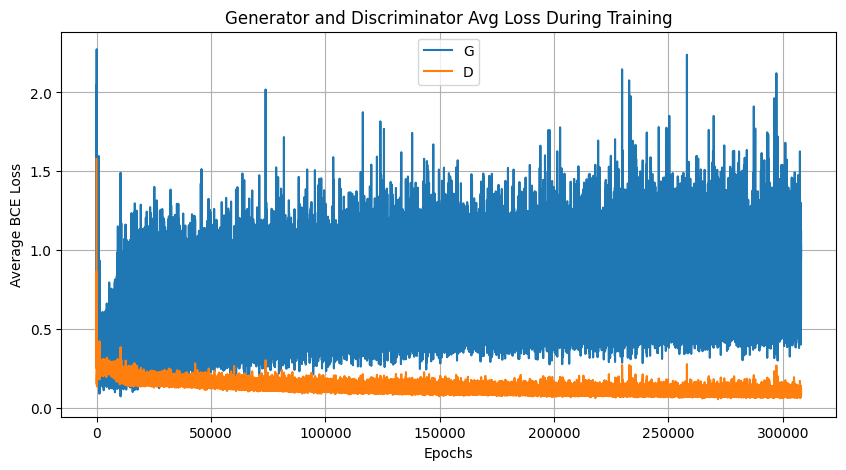

📉 Loss curve plot saved/shown (based on 308000 epochs).

Loading final Generator model and fixed preview data...
Loaded fixed_noise shape: torch.Size([16, 100])
Loaded fixed_fmri_condition shape: torch.Size([16, 1024])
Loaded real_images_for_preview shape: torch.Size([16, 3, 64, 64])
Generator loaded successfully.
Generating fake images for comparison...
Plotting Real vs. Final Fake images...


/tmp/ipykernel_19/2843049681.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fixed_noise = torch.load(FIXED_NOISE_PATH, map_location=device) # Load directly to device
/

📊 Real vs. Fake comparison plot saved/shown.


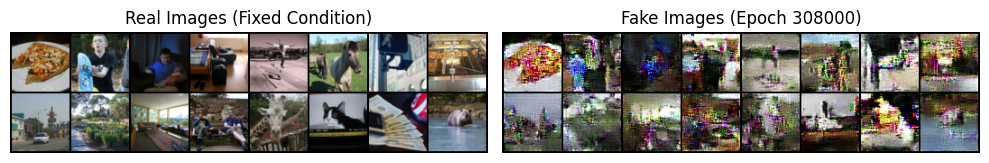

In [ ]:
N_COMPONENTS = 256
nz = 100
IMAGE_SIZE = 64


OUTPUT_BASE_DIR = '/kaggle/working/pca-SNGAN1024'
PREVIEW_DIR_CDCGAN = os.path.join(OUTPUT_BASE_DIR, 'previews')
CHECKPOINT_DIR_CDCGAN = os.path.join(OUTPUT_BASE_DIR, 'checkpoints')
LOSS_CURVE_G_PATH = os.path.join(OUTPUT_BASE_DIR, 'g_losses.npy')
LOSS_CURVE_D_PATH = os.path.join(OUTPUT_BASE_DIR, 'd_losses.npy')
FINAL_CKPT_G_PATH = os.path.join(CHECKPOINT_DIR_CDCGAN, 'netG_final.pth')
FIXED_NOISE_PATH = os.path.join(OUTPUT_BASE_DIR, 'fixed_noise.pt')
FIXED_FMRI_PATH = os.path.join(OUTPUT_BASE_DIR, 'fixed_fmri_condition.pt')
REAL_IMAGES_PREVIEW_PATH = os.path.join(OUTPUT_BASE_DIR, 'real_images_preview.pt')

REAL_SAMPLES_PNG_PATH = os.path.join(OUTPUT_BASE_DIR, 'real_samples_for_preview.png')


if not os.path.exists(OUTPUT_BASE_DIR):
    print(f"ERROR: Output directory {OUTPUT_BASE_DIR} not found. Cannot visualize results.")
else:

    print("Loading and plotting loss curves...")
    try:
        g_losses_loaded = np.load(LOSS_CURVE_G_PATH)
        d_losses_loaded = np.load(LOSS_CURVE_D_PATH)
        epochs_run = len(g_losses_loaded)

        plt.figure(figsize=(10,5))
        plt.title("Generator and Discriminator Avg Loss During Training")
        plt.plot(range(1, epochs_run + 1), g_losses_loaded, label="G")
        plt.plot(range(1, epochs_run + 1), d_losses_loaded, label="D")
        plt.xlabel("Epochs")
        plt.ylabel("Average BCE Loss")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(OUTPUT_BASE_DIR, 'loss_curve_epochs_loaded.png'))
        plt.show()
        print(f"📉 Loss curve plot saved/shown (based on {epochs_run} epochs).")
    except FileNotFoundError:
        print("Loss curve files (.npy) not found. Skipping plot.")
    except Exception as e:
        print(f"Error plotting loss curves: {e}")


    print("\nLoading final Generator model and fixed preview data...")
    fixed_noise = None
    fixed_fmri_condition = None
    real_images_for_preview = None
    netG_loaded = None

    try:

        if os.path.exists(FIXED_NOISE_PATH):
            fixed_noise = torch.load(FIXED_NOISE_PATH, map_location=device)
            print(f"Loaded fixed_noise shape: {fixed_noise.shape}")
        else:
            print(f"Warning: Saved fixed noise not found at {FIXED_NOISE_PATH}")

        if os.path.exists(FIXED_FMRI_PATH):
            fixed_fmri_condition = torch.load(FIXED_FMRI_PATH, map_location=device)
            print(f"Loaded fixed_fmri_condition shape: {fixed_fmri_condition.shape}")
        else:
            print(f"Warning: Saved fixed fmri condition not found at {FIXED_FMRI_PATH}")

        if os.path.exists(REAL_IMAGES_PREVIEW_PATH):
             real_images_for_preview = torch.load(REAL_IMAGES_PREVIEW_PATH, map_location='cpu')
             print(f"Loaded real_images_for_preview shape: {real_images_for_preview.shape}")
        else:
            print(f"Warning: Saved real images tensor not found at {REAL_IMAGES_PREVIEW_PATH}")


        if 'Generator' not in locals():
             try:
                 class Generator(nn.Module):
                     def __init__(self):
                         super(Generator, self).__init__()
                         self.fMRI_embed = nn.Linear(fMRI_dim, embedding_dim)
                         combined_input_dim = nz + embedding_dim
                         self.main = nn.Sequential(
                             nn.ConvTranspose2d(combined_input_dim, ngf * 8, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
                             nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
                             nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
                             nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf), nn.ReLU(True),
                             nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False), nn.Tanh())
                     def forward(self, noise, fmri_condition):
                         fmri_embedded = self.fMRI_embed(fmri_condition)
                         gen_input = torch.cat((noise, fmri_embedded), 1)
                         gen_input_reshaped = gen_input.unsqueeze(-1).unsqueeze(-1)
                         return self.main(gen_input_reshaped)
                 embedding_dim = 128; nc=3; ngf=64; fMRI_dim=N_COMPONENTS # Example values
             except NameError:
                  raise NameError("Generator class or its parameters not defined. Please run Cell 4 first.")


        netG_loaded = Generator().to(device)
        netG_loaded.load_state_dict(torch.load(FINAL_CKPT_G_PATH, map_location=device))
        netG_loaded.eval()
        print("Generator loaded successfully.")

        # --- Generate and Plot ---
        if netG_loaded is not None and fixed_noise is not None and fixed_fmri_condition is not None and real_images_for_preview is not None:
            print("Generating fake images for comparison...")
            with torch.no_grad():
                fake_preview = netG_loaded(fixed_noise, fixed_fmri_condition).detach().cpu()

            print("Plotting Real vs. Final Fake images...")
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            axes[0].axis("off")
            axes[0].set_title("Real Images (Fixed Condition)")
            axes[0].imshow(np.transpose(vutils.make_grid(real_images_for_preview.to('cpu'), # Ensure on CPU
                                                          padding=2, normalize=True).cpu(),(1,2,0)))

            axes[1].axis("off")
            axes[1].set_title(f"Fake Images (Epoch {epochs_run})") # Use loaded epoch count
            axes[1].imshow(np.transpose(vutils.make_grid(fake_preview, padding=2, normalize=True).cpu(),(1,2,0)))

            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_BASE_DIR, 'real_vs_fake_final_comparison_loaded.png'))
            print("📊 Real vs. Fake comparison plot saved/shown.")
            plt.show()
        else:
             print("Skipping Real vs Fake plot due to missing loaded components (model or fixed data).")

    except FileNotFoundError as e:
        print(f"Error: Required file not found: {e}. Skipping relevant visualization part.")
    except NameError as e:
         print(f"Error loading model/data: {e}. Ensure relevant definition cells were run.")
    except Exception as e:
        print(f"An error occurred during model loading or image generation: {e}")